# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [174]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [175]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [176]:
#!gunzip SUSY.csv.gz

In [177]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

filename="SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

In [178]:
# Before anything else, just looking at what I actually loaded.
print(df.shape)
print(df.head())

print(df['signal'].value_counts())
print('signal fraction:', round(df['signal'].mean(), 4))

(5000000, 19)
   signal    l_1_pT   l_1_eta   l_1_phi    l_2_pT   l_2_eta   l_2_phi  \
0     0.0  0.972861  0.653855  1.176225  1.157156 -1.739873 -0.874309   
1     1.0  1.667973  0.064191 -1.225171  0.506102 -0.338939  1.672543   
2     1.0  0.444840 -0.134298 -0.709972  0.451719 -1.613871 -0.768661   
3     1.0  0.381256 -0.976145  0.693152  0.448959  0.891753 -0.677328   
4     1.0  1.309996 -0.690089 -0.676259  1.589283 -0.693326  0.622907   

        MET   MET_phi   MET_rel  axial_MET       M_R    M_TR_2         R  \
0  0.567765 -0.175000  0.810061  -0.252552  1.921887  0.889637  0.410772   
1  3.475464 -1.219136  0.012955   3.775174  1.045977  0.568051  0.481928   
2  1.219918  0.504026  1.831248  -0.431385  0.526283  0.941514  1.587535   
3  2.033060  1.533041  3.046260  -1.005285  0.569386  1.015211  1.582217   
4  1.087562 -0.381742  0.589204   1.365479  1.179295  0.968218  0.728563   

        MT2       S_R  M_Delta_R  dPhi_r_b  cos_theta_r1  
0  1.145621  1.932632   0.99446

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA).

### Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 1: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning).

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 2: Training a Classifier

Lets' repeat what we did manually in the lecture using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [179]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [180]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]

We can train the classifier as follow:

In [181]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide <array_api>` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None
Name,Type,Value
"classes_ classes_: array-like of shape (n_classes,)Unique class labels.","ndarray[float64](2,)","[0.,1.]"
"coef_ coef_: ndarray of shape (n_features,) or (n_classes, n_features)Weight vector(s).","ndarray[float64](1, 18)","[[ 1.11,-0. ,-0. ,..., 0.86,-0.04, 2.58]]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If ``n_components`` is not set then all components are stored and thesum of explained variances is equal to 1.0. Only available when eigenor svd solver is used.","ndarray[float64](1,)",[1.]


We can plot the output, comparing signal and background:

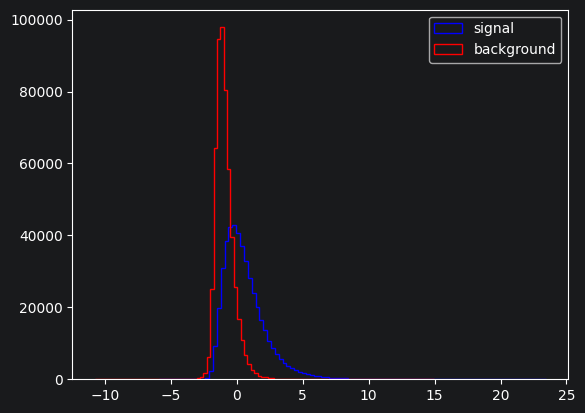

In [182]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a (10 Points)

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

1286076 322036


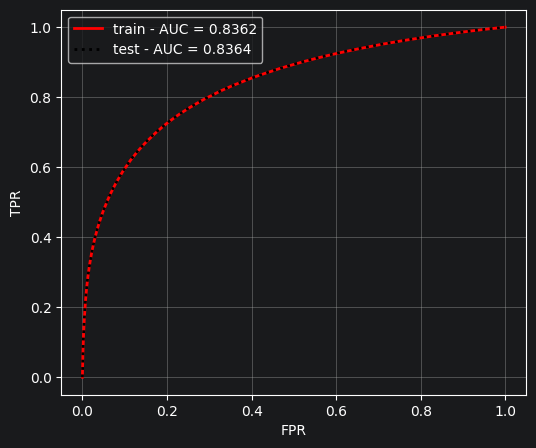

train AUC 0.83617 on 4000000 events
test AUC 0.8364 on 1000000 events
train - test = -0.00023


In [183]:
from sklearn.metrics import roc_curve, auc

fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

# roc_curve returns a point per unique score, so this is millions of points
print(len(fpr_train), len(fpr_test))

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6, 5))

# way too many points to actually draw, so every 1000th
plt.plot(fpr_train[::1000], tpr_train[::1000],
         color='red', linewidth=2, label=f'train - AUC = {round(auc_train, 4)}')
plt.plot(fpr_test[::1000], tpr_test[::1000],
         color='black', linestyle='dotted', linewidth=2, label=f'test - AUC = {round(auc_test, 4)}')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.grid()
plt.legend()
plt.show()

print(f'train AUC {round(auc_train, 5)} on {len(y_Train)} events')
print(f'test AUC {round(auc_test, 5)} on {len(y_Test)} events')
print(f'train - test = {round(auc_train - auc_test, 5)}')

In [184]:
for n in [200, 1000, 10000, 100000, 1000000]:
    small = df[:n]

    f = DA.LinearDiscriminantAnalysis()
    f.fit(small[VarNames[1:]], small['signal'])

    fpr_tr, tpr_tr, _ = roc_curve(small['signal'], f.decision_function(small[VarNames[1:]]))
    fpr_te, tpr_te, _ = roc_curve(y_Test, f.decision_function(X_Test))

    a_tr = auc(fpr_tr, tpr_tr)
    a_te = auc(fpr_te, tpr_te)

    print(f'N_Train {n}: train AUC {round(a_tr, 4)}, test AUC {round(a_te, 4)}, gap {round(a_tr - a_te, 4)}')

N_Train 200: train AUC 0.865, test AUC 0.8126, gap 0.0524
N_Train 1000: train AUC 0.8532, test AUC 0.8408, gap 0.0125
N_Train 10000: train AUC 0.8348, test AUC 0.8329, gap 0.0019
N_Train 100000: train AUC 0.8349, test AUC 0.837, gap -0.0021
N_Train 1000000: train AUC 0.8367, test AUC 0.8365, gap 0.0002


In [185]:
# There is essentially zero bias here.
# I think the model is too small to reasonably memorize the whole dataset.

#### Part b (10 Points)

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot.

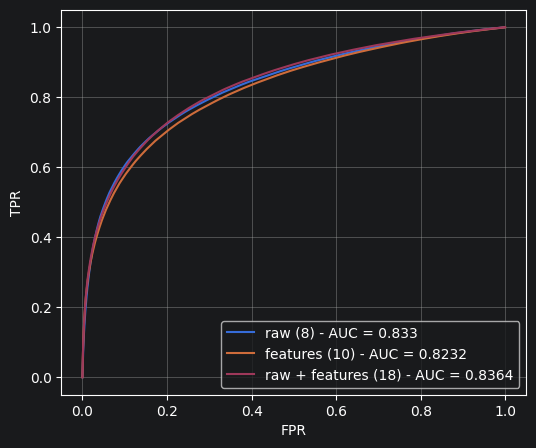

{'raw': 0.833, 'features': 0.8232, 'raw + features': 0.8364}


In [186]:
input_sets = {
    'raw': RawNames,
    'features': FeatureNames,
    'raw + features': VarNames[1:],
}

plt.figure(figsize=(6, 5))
aucs = {}

for label, cols in input_sets.items():
    clf = DA.LinearDiscriminantAnalysis()
    clf.fit(Train_Sample[cols], y_Train)

    fpr, tpr, _ = roc_curve(y_Test, clf.decision_function(Test_Sample[cols]))
    roc_auc = auc(fpr, tpr)
    aucs[label] = round(roc_auc, 4)

    plt.plot(fpr[::1000], tpr[::1000], label=f'{label} ({len(cols)}) - AUC = {round(roc_auc, 4)}')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.grid()
plt.legend()
plt.show()

print(aucs)

In [187]:
# Raw + features has the best outcome, although the engineered features are not adding very much.

Exercise 3: Comparing Techniques

#### Part a (10 Points)
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b (10 Points)

Write a function that takes an instantiated classifier and performs the comparison from part 2b. Use the function on your choice of functions in part a.

#### Part c (10 Points)

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 7.

In [188]:
# Part A
# KNN: I am familiar with this technique, so I had to pick it as one of the models. Classifies based on nearest neighbor vote.
# HistGradientBoostingClassifier: From what I can see this is a "tree ensemble", from the docs: "These histogram-based estimators can be orders of magnitude faster than GradientBoostingClassifier and GradientBoostingRegressor when the number of samples is larger than tens of thousands of samples." which sound very interesting.
# GaussianNB: Probability based.

100000 50000


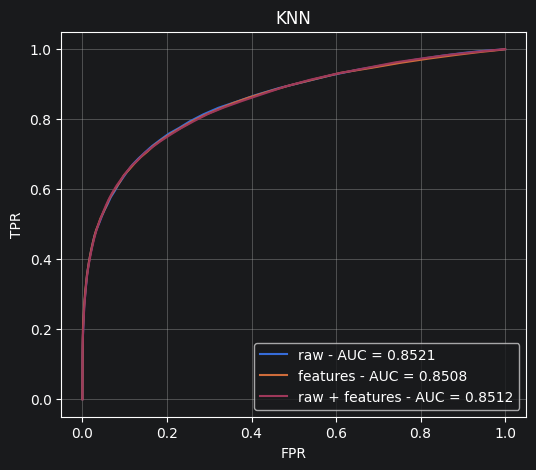

KNN {'raw': 0.8521, 'features': 0.8508, 'raw + features': 0.8512}


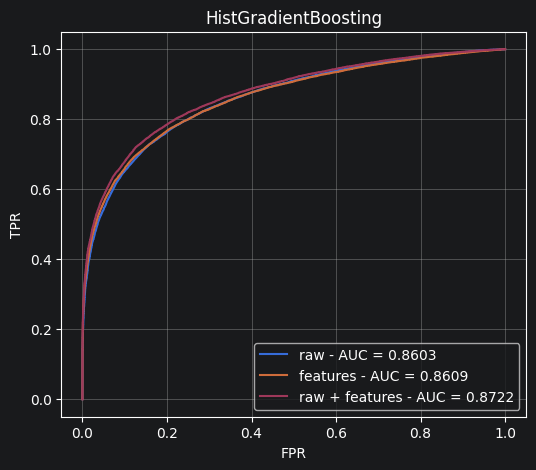

HistGradientBoosting {'raw': 0.8603, 'features': 0.8609, 'raw + features': 0.8722}


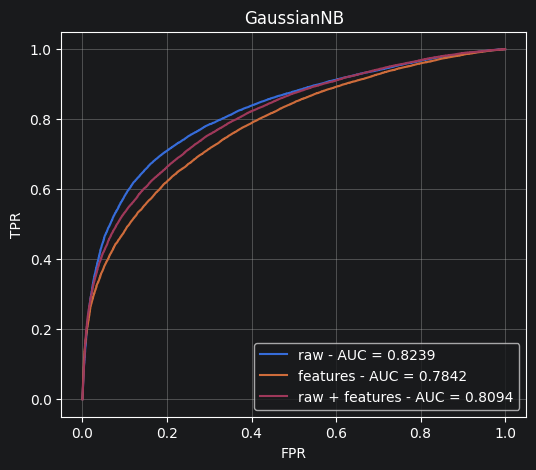

GaussianNB {'raw': 0.8239, 'features': 0.7842, 'raw + features': 0.8094}


In [189]:
# Part B
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

N_Train_Ex3 = 100000
N_Test_Ex3 = 50000

Train_Ex3 = df[:N_Train_Ex3]
Test_Ex3 = df[N_Train_Ex3:N_Train_Ex3 + N_Test_Ex3]

y_Train_Ex3 = Train_Ex3['signal']
y_Test_Ex3 = Test_Ex3['signal']

print(len(Train_Ex3), len(Test_Ex3))

# KNN works off distances, had to used the standard scaler.
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=50, n_jobs=-1))
hgb = HistGradientBoostingClassifier(random_state=0)
gnb = GaussianNB()

def compare_inputs(clf, name):
    input_sets = {
        'raw': RawNames,
        'features': FeatureNames,
        'raw + features': VarNames[1:],
    }

    plt.figure(figsize=(6, 5))
    aucs = {}

    for label, cols in input_sets.items():
        clf.fit(Train_Ex3[cols], y_Train_Ex3)

        scores = clf.predict_proba(Test_Ex3[cols])[:, 1]

        fpr, tpr, _ = roc_curve(y_Test_Ex3, scores)
        roc_auc = auc(fpr, tpr)
        aucs[label] = round(roc_auc, 4)

        plt.plot(fpr, tpr, label=f'{label} - AUC = {round(roc_auc, 4)}')

    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(name)
    plt.grid()
    plt.legend()
    plt.show()

    print(name, aucs)

    return aucs


knn_aucs = compare_inputs(knn, 'KNN')
hgb_aucs = compare_inputs(hgb, 'HistGradientBoosting')
gnb_aucs = compare_inputs(gnb, 'GaussianNB')

first 3 thresholds: [       inf 0.99939487 0.99934684]
scenario 1 (N_S 20, N_B 200): best 2.563 at x_c 0.8029, TPR 0.488, FPR 0.024
scenario 2 (N_S 200, N_B 2000): best 8.107 at x_c 0.8029, TPR 0.488, FPR 0.024
scenario 3 (N_S 2000, N_B 20000): best 25.635 at x_c 0.8029, TPR 0.488, FPR 0.024
scenario 4 (N_S 20000, N_B 200000): best 81.065 at x_c 0.8029, TPR 0.488, FPR 0.024


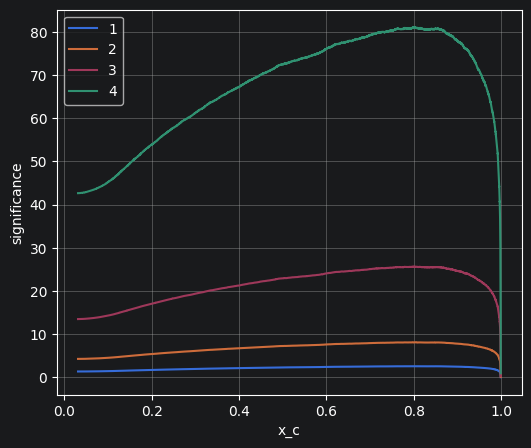

In [190]:
# Part C
# HistGradientBoosting had the best AUC, so I'll use it here.
# Lab 7 scenarios:
scenarios = {'1': (20, 200), '2': (200, 2000), '3': (2000, 20000), '4': (20000, 200000)}

def significance(TPR, FPR, n_sig_expected, n_bkg_expected):
    n_sig_expected_prime = n_sig_expected * TPR
    n_bkg_expected_prime = n_bkg_expected * FPR

    return n_sig_expected_prime / np.sqrt(n_sig_expected_prime + n_bkg_expected_prime + 0.001)


hgb.fit(Train_Ex3[VarNames[1:]], y_Train_Ex3)
scores = hgb.predict_proba(Test_Ex3[VarNames[1:]])[:, 1]

FPR, TPR, thresholds = roc_curve(y_Test_Ex3, scores)

print('first 3 thresholds:', thresholds[:3])

FPR = FPR[1:]
TPR = TPR[1:]
thresholds = thresholds[1:]

plt.figure(figsize=(6, 5))

for name, (sigexp, bkgexp) in scenarios.items():
    sig = significance(TPR, FPR, sigexp, bkgexp)

    max_i = 0
    for i in range(len(sig)):
        if sig[i] > sig[max_i]:
            max_i = i

    print(f'scenario {name} (N_S {sigexp}, N_B {bkgexp}): best {round(sig[max_i], 3)} at x_c {round(thresholds[max_i], 4)}, TPR {round(TPR[max_i], 3)}, FPR {round(FPR[max_i], 3)}')

    plt.plot(thresholds, sig, label=name)

plt.xlabel('x_c')
plt.ylabel('significance')
plt.grid()
plt.legend()
plt.show()

In [191]:
for name, (sigexp, bkgexp) in scenarios.items():
    print(name, sigexp, bkgexp, 'N_B / N_S =', bkgexp // sigexp)

print('sqrt(10) =', round(np.sqrt(10), 3))

1 20 200 N_B / N_S = 10
2 200 2000 N_B / N_S = 10
3 2000 20000 N_B / N_S = 10
4 20000 200000 N_B / N_S = 10
sqrt(10) = 3.162


### Exercise 4: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

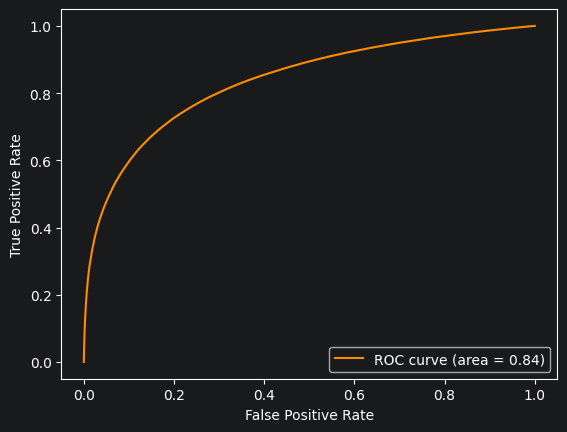

In [192]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

#### Part a (10 Points)
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b (10 Points)
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance.


In [193]:
# Part A: Completed the reading.

In [194]:
# Part B: I'll assume I'm looking at the model from 3C here.
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

roc_auc = auc(FPR, TPR)

print('signal fraction in the test slice:', round(y_Test_Ex3.mean(), 4))

rows = []

for name, (sigexp, bkgexp) in scenarios.items():
    sig = significance(TPR, FPR, sigexp, bkgexp)

    max_i = 0
    for i in range(len(sig)):
        if sig[i] > sig[max_i]:
            max_i = i
    best_cut = thresholds[max_i]
    y_pred = (scores >= best_cut).astype(int)

    rows.append(['scenario ' + name,
                 sigexp,
                 bkgexp,
                 round(best_cut, 4),
                 round(TPR[max_i], 4),
                 round(FPR[max_i], 4),
                 round(precision_score(y_Test_Ex3, y_pred), 4),
                 round(recall_score(y_Test_Ex3, y_pred), 4),
                 round(f1_score(y_Test_Ex3, y_pred), 4),
                 round(accuracy_score(y_Test_Ex3, y_pred), 4),
                 round(roc_auc, 4),
                 round(sig[max_i], 3)])

headers = ['', 'N_S', 'N_B', 'x_c', 'TPR', 'FPR', 'precision', 'recall', 'F1',
           'accuracy', 'AUC', 'significance']

print(rows[0])
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))

signal fraction in the test slice: 0.4552
['scenario 1', 20, 200, np.float64(0.8029), np.float64(0.4876), np.float64(0.0236), 0.9452, 0.4876, 0.6434, 0.7539, 0.8722, np.float64(2.563)]


,N_S,N_B,x_c,TPR,FPR,precision,recall,F1,accuracy,AUC,significance
scenario 1,20,200,0.8029,0.4876,0.0236,0.9452,0.4876,0.6434,0.7539,0.8722,2.563
scenario 2,200,2000,0.8029,0.4876,0.0236,0.9452,0.4876,0.6434,0.7539,0.8722,8.107
scenario 3,2000,20000,0.8029,0.4876,0.0236,0.9452,0.4876,0.6434,0.7539,0.8722,25.635
scenario 4,20000,200000,0.8029,0.4876,0.0236,0.9452,0.4876,0.6434,0.7539,0.8722,81.065


### Deep Learning Model

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample.

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

### Exercise 5 (10 Points)

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs.
* Compare the performance on training versus test sample. Are you over training?

In [195]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


In [196]:
from sklearn.preprocessing import StandardScaler


def plot_history(history, name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], color='red', linewidth=2, label='train')
    plt.plot(history.history['val_loss'], color='black', linestyle='dotted', linewidth=2, label='test')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(name)
    plt.grid()
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], color='red', linewidth=2, label='train')
    plt.plot(history.history['val_accuracy'], color='black', linestyle='dotted', linewidth=2, label='test')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title(name)
    plt.grid()
    plt.legend()

    plt.tight_layout()
    plt.show()

    final_train = history.history['accuracy'][-1]
    final_test = history.history['val_accuracy'][-1]

    print(f'{name}: final train accuracy {round(final_train, 4)}, test accuracy {round(final_test, 4)}, gap {round(final_train - final_test, 4)}')

### Exercise 6 (10 Points)

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

(500000, 18) (50000, 18)
column means after scaling: [-0.  0.  0. -0.  0.]
training model 1 (small, adam)


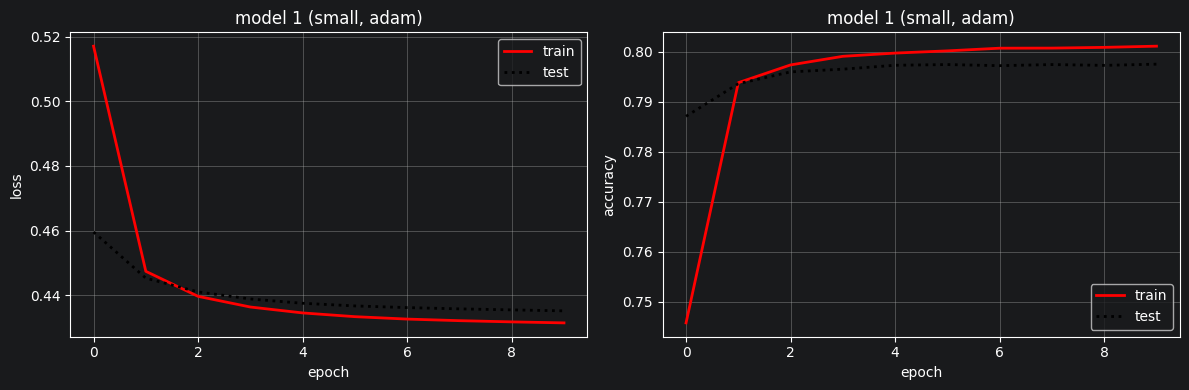

model 1 (small, adam): final train accuracy 0.8011, test accuracy 0.7975, gap 0.0036
AUC 0.8712
training model 2 (deeper, adam)


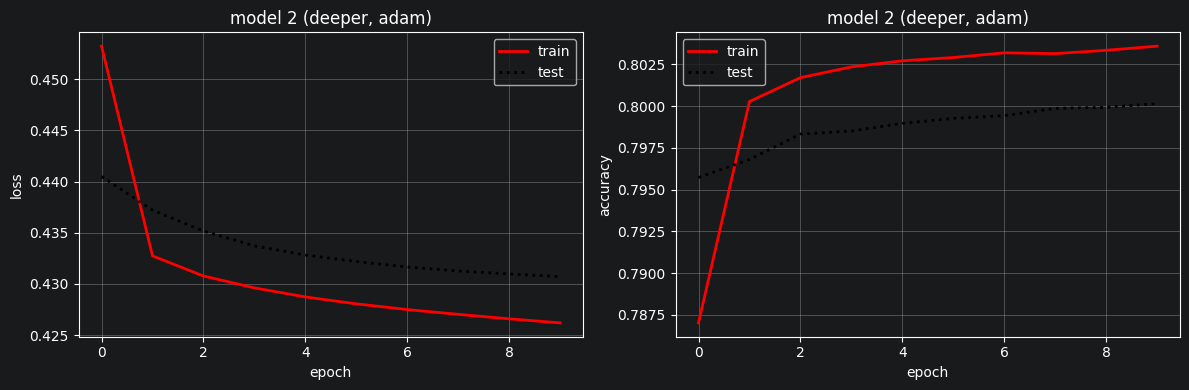

model 2 (deeper, adam): final train accuracy 0.8036, test accuracy 0.8001, gap 0.0034
AUC 0.874
training model 3 (deeper, sgd)


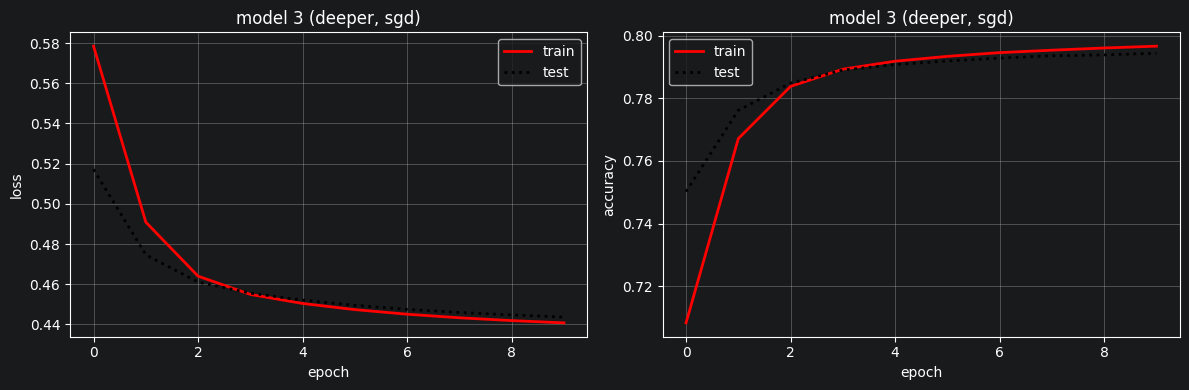

model 3 (deeper, sgd): final train accuracy 0.7966, test accuracy 0.7944, gap 0.0022
AUC 0.8657
{'model 1 (small, adam)': 0.8712, 'model 2 (deeper, adam)': 0.874, 'model 3 (deeper, sgd)': 0.8657}


In [197]:
import keras
from keras import layers

scaler = StandardScaler()
X_Train_scaled = scaler.fit_transform(X_Train)
X_Test_scaled = scaler.transform(X_Test)

print(X_Train_scaled.shape, X_Test_scaled.shape)
print('column means after scaling:', np.round(X_Train_scaled.mean(axis=0)[:5], 4))

keras.utils.set_random_seed(0)

def build_model_1(n_inputs):
    model = keras.Sequential([
        layers.Input(shape=(n_inputs,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_2(n_inputs):
    model = keras.Sequential([
        layers.Input(shape=(n_inputs,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_3(n_inputs):
    model = keras.Sequential([
        layers.Input(shape=(n_inputs,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    return model


n_inputs = X_Train_scaled.shape[1]

models = {
    'model 1 (small, adam)': build_model_1(n_inputs),
    'model 2 (deeper, adam)': build_model_2(n_inputs),
    'model 3 (deeper, sgd)': build_model_3(n_inputs),
}

histories = {}
dnn_aucs = {}

for name in models:
    print('training', name)

    history = models[name].fit(X_Train_scaled, y_Train,
                               validation_data=(X_Test_scaled, y_Test),
                               epochs=10, batch_size=1024, verbose=0)
    histories[name] = history

    plot_history(history, name)

    dnn_scores = models[name].predict(X_Test_scaled, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_Test, dnn_scores)
    dnn_aucs[name] = round(auc(fpr, tpr), 4)

    print(f'AUC {dnn_aucs[name]}')

print(dnn_aucs)

In [198]:
# Exercise 5
# Model 1: Flattens out pretty early. Train and test stay close,
# Model 2: Mostly flat by the end, best AUC and the gap is pretty small
# Model 3: looks like its still climbing at epoch 10, maybe more epochs could help.

## Exercise 7 (10 Points)

Repeat exercise 3, adding your best performing DNN as one of the models.  


best DNN was model 2 (deeper, adam) at AUC 0.874


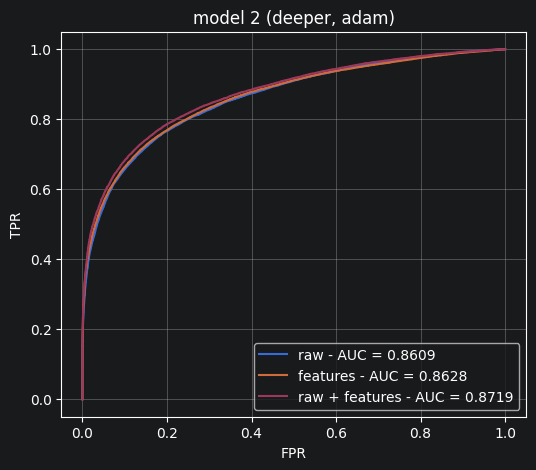

model 2 (deeper, adam) {'raw': 0.8609, 'features': 0.8628, 'raw + features': 0.8719}
['KNN', 0.8521, 0.8508, 0.8512]


,raw,features,raw + features
KNN,0.8521,0.8508,0.8512
GaussianNB,0.8239,0.7842,0.8094
HistGradientBoosting,0.8603,0.8609,0.8722
"model 2 (deeper, adam)",0.8609,0.8628,0.8719


In [199]:
builders = {
    'model 1 (small, adam)': build_model_1,
    'model 2 (deeper, adam)': build_model_2,
    'model 3 (deeper, sgd)': build_model_3,
}

best_dnn = ''
for name in dnn_aucs:
    if best_dnn == '' or dnn_aucs[name] > dnn_aucs[best_dnn]:
        best_dnn = name

print('best DNN was', best_dnn, 'at AUC', dnn_aucs[best_dnn])


def compare_inputs_dnn(build_function, name):
    input_sets = {
        'raw': RawNames,
        'features': FeatureNames,
        'raw + features': VarNames[1:],
    }

    plt.figure(figsize=(6, 5))
    aucs = {}

    for label, cols in input_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(np.array(Train_Ex3[cols]))
        X_te = scaler.transform(np.array(Test_Ex3[cols]))

        model = build_function(X_tr.shape[1])
        model.fit(X_tr, np.array(y_Train_Ex3), epochs=10, batch_size=1024, verbose=0)

        dnn_scores = model.predict(X_te, verbose=0).flatten()

        fpr, tpr, _ = roc_curve(y_Test_Ex3, dnn_scores)
        roc_auc = auc(fpr, tpr)
        aucs[label] = round(roc_auc, 4)

        plt.plot(fpr, tpr, label=f'{label} - AUC = {round(roc_auc, 4)}')

    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(name)
    plt.grid()
    plt.legend()
    plt.show()

    print(name, aucs)

    return aucs


dnn_input_aucs = compare_inputs_dnn(builders[best_dnn], best_dnn)

rows = []
for label, aucs in [('KNN', knn_aucs),
                    ('GaussianNB', gnb_aucs),
                    ('HistGradientBoosting', hgb_aucs),
                    (best_dnn, dnn_input_aucs)]:
    rows.append([label, aucs['raw'], aucs['features'], aucs['raw + features']])

print(rows[0])
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=['', 'raw', 'features', 'raw + features'])))